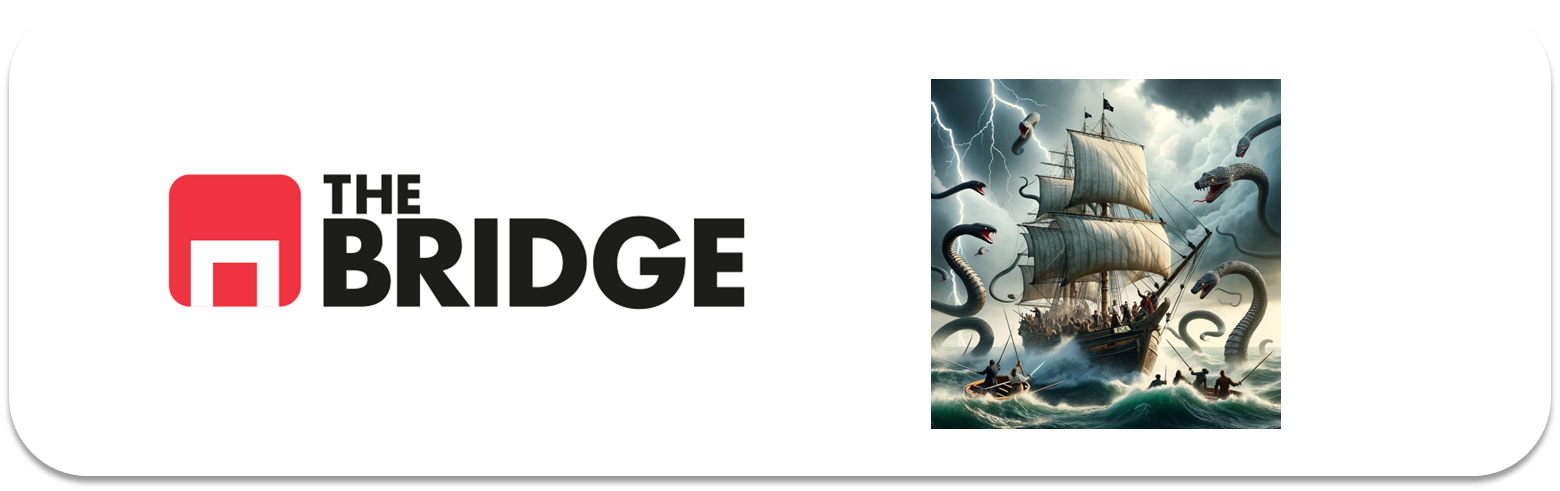

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técnicas de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [36]:
import bootcampviztools as bt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split


from scipy.stats import pearsonr
from scipy import stats
from scipy.stats import mannwhitneyu



### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


**0: Carga y exploración inicial**

In [3]:
df = pd.read_csv("./data/credit_npo.csv")
df.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
5,0,0.101002,61,0,0.217115,15880.0,5,0,1,0,0.0
6,0,0.222830,60,0,0.907083,1312.0,5,0,0,0,0.0
7,0,0.353443,39,0,0.764309,4000.0,11,0,1,0,2.0
8,0,0.772455,45,0,0.387179,5100.0,5,0,1,0,3.0
9,0,0.116165,44,0,0.160236,10833.0,8,0,1,0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [5]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


**1: Eliminación de nulos y conversión a cat:**

In [10]:
df.isnull().sum()

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

In [11]:
df_credit = df.copy()
df_credit = df_credit.dropna().reset_index(drop=True)
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11816 entries, 0 to 11815
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  int64  
 4   DebtRatio                             11816 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 7   NumberOfTimes90DaysLate               11816 non-null  int64  
 8   NumberRealEstateLoansOrLines          11816 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  int64  
 10  NumberOfDependents                    11816 non-null  float64
dtypes: float64(4), 

In [15]:
# veo primero los valores distintos de cada col para ver qué cantidad :
number_cols = [col for col in df_credit.columns if col.startswith('NumberOf')]
for col in number_cols:
    print(df_credit[col].value_counts().sort_index())

NumberOfTime30-59DaysPastDueNotWorse
0     9818
1     1354
2      397
3      127
4       64
5       23
6       20
7        1
8        2
98      10
Name: count, dtype: int64
NumberOfOpenCreditLinesAndLoans
0      112
1      307
2      445
3      638
4      848
5      963
6     1031
7     1110
8     1009
9      965
10     765
11     719
12     574
13     454
14     365
15     338
16     236
17     216
18     151
19     129
20     118
21      62
22      61
23      39
24      38
25      30
26      19
27      16
28      13
29      10
30      10
31       7
32       3
33       4
34       2
35       2
36       1
38       1
40       1
41       1
43       1
48       1
49       1
Name: count, dtype: int64
NumberOfTimes90DaysLate
0     11156
1       394
2       142
3        54
4        31
5        14
6         6
7         3
8         3
9         1
10        1
13        1
98       10
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse
0     11206
1       478
2        85
3        18
4    

In [25]:
 
df_credit['NumberOfTime30-59DaysPastDueNotWorse'] = pd.cut(
    df_credit['NumberOfTime30-59DaysPastDueNotWorse'], 
    bins=[-1, 0, 1, np.inf], # límites de los intervalos, , pd.cut excluye el límite izquierdo por defecto, y como haremos 0,1,2, entonces empieza en -1.
    labels=[0, 1, 2]
).astype('category')

In [26]:
# las paso a categóricas, las elijo todas, la distribución de los valores se concentra en valores bajos con outliers altos

df_credit['NumberOfOpenCreditLinesAndLoans'] = pd.cut(
    df_credit['NumberOfOpenCreditLinesAndLoans'], 
    bins=[-1, 0, 1, np.inf], # límites de los intervalos, , pd.cut excluye el límite izquierdo por defecto, y como haremos 0,1,2, entonces empieza en -1.
    labels=[0, 1, 2]
).astype('category')

In [27]:
df_credit['NumberOfTimes90DaysLate'] = pd.cut(
    df_credit['NumberOfTimes90DaysLate'], 
    bins=[-1, 0, 1, np.inf], # límites de los intervalos, , pd.cut excluye el límite izquierdo por defecto, y como haremos 0,1,2, entonces empieza en -1.
    labels=[0, 1, 2]
).astype('category')

In [28]:
df_credit['NumberOfTime60-89DaysPastDueNotWorse'] = pd.cut(
    df_credit['NumberOfTime60-89DaysPastDueNotWorse'], 
    bins=[-1, 0, 1, np.inf], # límites de los intervalos, , pd.cut excluye el límite izquierdo por defecto, y como haremos 0,1,2, entonces empieza en -1.
    labels=[0, 1, 2]
).astype('category')

In [29]:
df_credit['NumberOfDependents'] = pd.cut(
    df_credit['NumberOfDependents'], 
    bins=[-1, 0, 1, np.inf], # límites de los intervalos, , pd.cut excluye el límite izquierdo por defecto, y como haremos 0,1,2, entonces empieza en -1.
    labels=[0, 1, 2]
).astype('category')

In [33]:
# lo vuelvo a revisar para confirmar que cambiaron sus valores:
number_cols = [col for col in df_credit.columns if col.startswith('NumberOf')]
for col in number_cols:
    print(df_credit[col].value_counts().sort_index())
    print(f"dtype: {df_credit[col].dtype}")

NumberOfTime30-59DaysPastDueNotWorse
0    9818
1    1354
2     644
Name: count, dtype: int64
dtype: category
NumberOfOpenCreditLinesAndLoans
0      112
1      307
2    11397
Name: count, dtype: int64
dtype: category
NumberOfTimes90DaysLate
0    11156
1      394
2      266
Name: count, dtype: int64
dtype: category
NumberOfTime60-89DaysPastDueNotWorse
0    11206
1      478
2      132
Name: count, dtype: int64
dtype: category
NumberOfDependents
0    6413
1    2369
2    3034
Name: count, dtype: int64
dtype: category


In [34]:
# reconfirmo, tengo ahora 5 categóricas:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11816 entries, 0 to 11815
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   SeriousDlqin2yrs                      11816 non-null  int64   
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64 
 2   age                                   11816 non-null  int64   
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  category
 4   DebtRatio                             11816 non-null  float64 
 5   MonthlyIncome                         11816 non-null  float64 
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  category
 7   NumberOfTimes90DaysLate               11816 non-null  category
 8   NumberRealEstateLoansOrLines          11816 non-null  int64   
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  category
 10  NumberOfDependents                    11816 non-null  category
dtypes:

In [37]:
X = df_credit.drop("SeriousDlqin2yrs", axis=1)
y = df_credit["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**2.1: mini-EDA:**

In [38]:
features_num = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome", "NumberRealEstateLoansOrLines"]

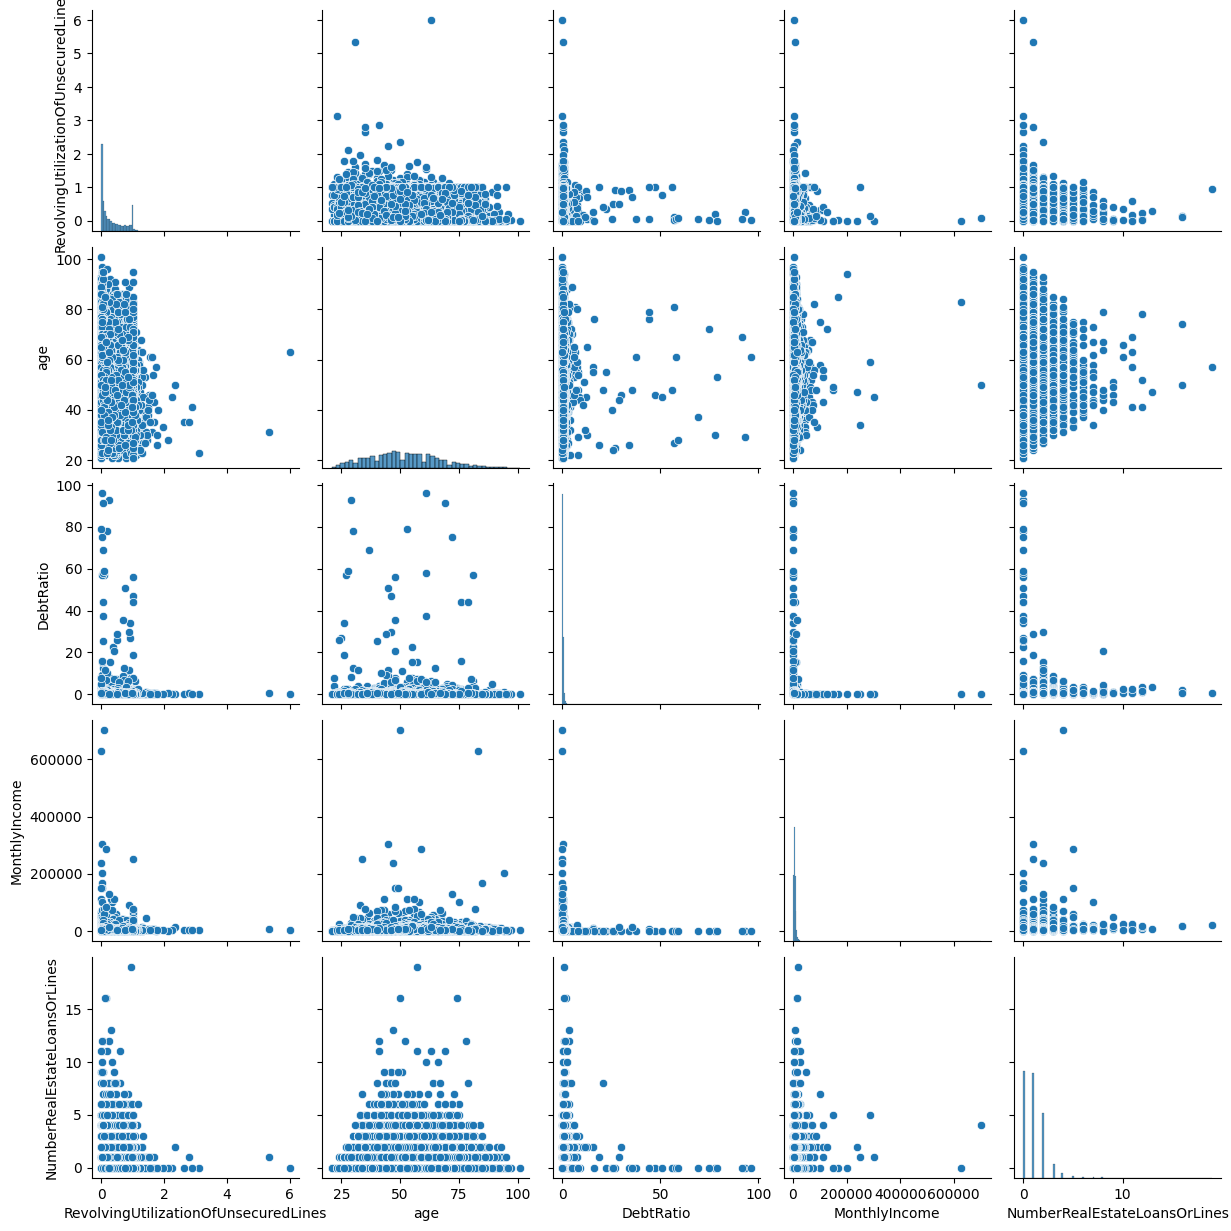

In [41]:
# vemos distribuciones de las numéricas:

sns.pairplot(df_credit[features_num]);

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.